<a href="https://colab.research.google.com/github/fabianoseller/PucPosEstat/blob/main/TF_Inferencia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Trabalho Final de Inferência Estatística**
Fabiano Antunes, Felipe Magno, Gabriela Araújo

#### **Importação de bibliotecas utilizadas**

In [ ]:
# !pip install pingouin
# !pip install scikit_posthocs

In [ ]:
# 📦 Importação de bibliotecas

# Manipulação de dados
import pandas as pd
import numpy as np
from statistics import mean, stdev

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Modelagem estatística
import statsmodels.api as sm
from statsmodels.graphics.gofplots import qqplot
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import lilliefors, het_breuschpagan
from statsmodels.stats.weightstats import ztest
import pandas as pd
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm # Para gráficos QQ-plot

# Testes estatísticos
from scipy.stats import chi2_contingency, normaltest, norm, shapiro
from statsmodels.stats.anova import AnovaRM
from statsmodels.stats.multicomp import MultiComparison
import statsmodels.stats.multicomp as mc
import scipy.stats as stats
import itertools
import pingouin as pg
from scipy.stats import kruskal
import scikit_posthocs as sp

# Warnings
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

## **Teste 1**

Vamos analisar se existe diferença significativa no score de obsessões (Y-BOCS) entre pacientes do sexo feminino e masculino com Transtorno Obsessivo-Compulsivo (TOC).

### **Hipóteses**
**Hipótese nula (H₀):** Não há diferença significativa no score médio de obsessões Y-BOCS entre pacientes do sexo feminino e masculino.

**Hipótese alternativa (H₁):** Há diferença significativa no score médio de obsessões Y-BOCS entre pacientes do sexo feminino e masculino.


**Nível de significância: α = 0.05**

### **Análise dos dados**

In [ ]:
# Carregar os dados
df = pd.read_csv('ocd_patient_dataset.csv')

df.head()

,Patient ID,Age,Gender,Ethnicity,Marital Status,Education Level,OCD Diagnosis Date,Duration of Symptoms (months),Previous Diagnoses,Family History of OCD,Obsession Type,Compulsion Type,Y-BOCS Score (Obsessions),Y-BOCS Score (Compulsions),Depression Diagnosis,Anxiety Diagnosis,Medications
0,1018,32,Female,African,Single,Some College,2016-07-15,203,MDD,No,Harm-related,Checking,17,10,Yes,Yes,SNRI
1,2406,69,Male,African,Divorced,Some College,2017-04-28,180,NaN,Yes,Harm-related,Washing,21,25,Yes,Yes,SSRI
2,1188,57,Male,Hispanic,Divorced,College Degree,2018-02-02,173,MDD,No,Contamination,Checking,3,4,No,No,Benzodiazepine
3,6200,27,Female,Hispanic,Married,College Degree,2014-08-25,126,PTSD,Yes,Symmetry,Washing,14,28,Yes,Yes,SSRI
4,5824,56,Female,Hispanic,Married,High School,2022-02-20,168,PTSD,Yes,Hoarding,Ordering,39,18,No,No,NaN


        count       mean        std  min   25%   50%   75%   max
Gender                                                          
Female  747.0  20.195448  11.719091  0.0  10.0  20.0  31.0  40.0
Male    753.0  19.901726  11.932920  0.0  10.0  20.0  30.0  40.0


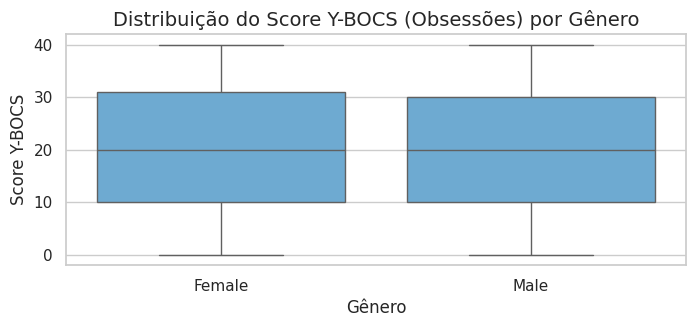

In [ ]:
# Descritiva
print(df.groupby('Gender')['Y-BOCS Score (Obsessions)'].describe())

# Visualização
plt.figure(figsize=(8, 3))
sns.boxplot(x='Gender', y='Y-BOCS Score (Obsessions)', data=df, color = "#5DADE2")
plt.title('Distribuição do Score Y-BOCS (Obsessões) por Gênero', fontsize = 14)
plt.xlabel('Gênero', fontsize = 12)
plt.ylabel('Score Y-BOCS', fontsize = 12)
plt.show()

### **Teste Estatístico**

In [ ]:
#Teste de normalidade dos dados
#H₀: Os dados são normalmente distribuídos
#H₁: Os dados não são normalmente distribuídos

female_scores = df[df['Gender'] == 'Female']['Y-BOCS Score (Obsessions)']
male_scores = df[df['Gender'] == 'Male']['Y-BOCS Score (Obsessions)']

# Shapiro-Wilk
shapiro_female = stats.shapiro(female_scores)
shapiro_male = stats.shapiro(male_scores)

print(f"Shapiro-Wilk para mulheres: estatística={shapiro_female[0]}, p-valor={shapiro_female[1]}")
print(f"Shapiro-Wilk para homens: estatística={shapiro_male[0]}, p-valor={shapiro_male[1]}")

Shapiro-Wilk para mulheres: estatística=0.9549341314901955, p-valor=2.3545623948789993e-14
Shapiro-Wilk para homens: estatística=0.9505850603373208, p-valor=3.470521840570993e-15


Para ambos o P-valor é maior que 0,05. por tanto não rejeitamos a hipotese de normalidade.

In [ ]:
#Teste de Homogeneidade e Variância.
levene_test = stats.levene(female_scores, male_scores)
print(f"Teste de Levene: estatística={levene_test[0]}, p-valor={levene_test[1]}")

Teste de Levene: estatística=0.5243464834357745, p-valor=0.46910653120857493


In [ ]:
#Teste T
t_test = stats.ttest_ind(female_scores, male_scores, equal_var=True)
print(f"Teste t: estatística={t_test[0]}, p-valor={t_test[1]}")

Teste t: estatística=0.48092476381533655, p-valor=0.630640204204719


### **Conclusão Final:**
 P-Valor ≥ 0.05: Não há diferença significativa no score médio de obsessões Y-BOCS entre pacientes do sexo feminino e masculino.

 ---------------------------------------------------------------------------

## **Teste 2**

Avaliar se existe diferença na proporção de pessoas com distúrbio do sono (Insônia) entre as diferentes ocupações.

### **Hipóteses:**

**Hipótese nula (H₀):** A proporção de pessoas com insônia é a mesma em todas as ocupações.

**Hipótese alternativa (H₁):** Pelo menos uma ocupação tem proporção de insônia diferente das demais.

**Nível de significância: α = 0.05**

### **Análise dos dados**

In [ ]:
#Carregar dados
df = pd.read_csv('Sleep_health_and_lifestyle_dataset.csv')

df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,No
1,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,No
2,7,Male,29,Teacher,6.3,6,40,7,Obese,140/90,82,3500,Insomnia
3,8,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,No
4,9,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,No


Como estamos comparando proporções em mais de dois grupos categóricos, o teste mais adequado é o teste qui-quadrado de independência.

**Validação das Suposições:**

* Dados categóricos: Sim (ocupação × distúrbio do sono).

* Amostras independentes: Sim (cada pessoa pertence a apenas uma ocupação).

* Frequências esperadas: Devemos verificar se pelo menos 80% das células têm frequência esperada ≥ 5.



In [ ]:
print(df[['Occupation', 'Sleep Disorder']].head())

# Converter "Sleep Disorder" em binário (Insônia = True, outros = False)
df['Has_Insomnia'] = df['Sleep Disorder'] == 'Insomnia'

# Criar tabela de contingência
observed_table = pd.crosstab(df['Occupation'], df['Has_Insomnia'])

# Renomear colunas
observed_table.columns = ['No_Insomnia', 'Insomnia']
print(observed_table)

  Occupation Sleep Disorder
0     Doctor             No
1     Doctor             No
2    Teacher       Insomnia
3     Doctor             No
4     Doctor             No
             No_Insomnia  Insomnia
Occupation                        
Accountant            30         7
Doctor                64         3
Engineer              57         5
Lawyer                42         2
Nurse                  9         3
Salesperson            2        29
Teacher                9        27


In [ ]:
#Cálculo da frequência esperada pra cada celula.

observed = np.array([
    [30,  7],
    [64,  3],
    [57,  5],
    [42,  2],
    [ 9,  3],
    [ 2, 29],
    [ 9, 27]
])

chi2, p, dof, expected = chi2_contingency(observed)
print("Frequências esperadas:\n", expected)

Frequências esperadas:
 [[27.26989619  9.73010381]
 [49.38062284 17.61937716]
 [45.69550173 16.30449827]
 [32.42906574 11.57093426]
 [ 8.84429066  3.15570934]
 [22.84775087  8.15224913]
 [26.53287197  9.46712803]]


**Conclusão: Proporções significativamente menores que o esperado.**

### **Teste Estatístico**

In [ ]:
#Teste Qui-Quadrado
chi2, p, dof, expected = chi2_contingency(observed)
print(f"Estatística qui-quadrado: {chi2:.2f}")
print(f"p-value: {p:.4f}")

Estatística qui-quadrado: 155.28
p-value: 0.0000


#### **Conclusão do Teste:**

 p-value 0.0000 (p < 0.05) - Rejeitamos a hipótese nula.

Há diferença estatisticamente significativa na proporção de insônia entre as ocupações.

### **Post Hoc**

In [ ]:
#Teste post hoc para saber em quais ocupações estão as diferenças
# Lista de ocupações
occupations = observed_table.index

# Ajuste de Bonferroni: α = 0.05 / número de comparações
alpha = 0.05
n_comparisons = len(occupations) * (len(occupations) - 1) / 2
adjusted_alpha = alpha / n_comparisons

print(f"α ajustado (Bonferroni): {adjusted_alpha:.4f}")

# Comparações pareadas
for pair in itertools.combinations(occupations, 2):
    subset = observed_table.loc[list(pair)]
    _, p_posthoc, _, _ = chi2_contingency(subset)
    if p_posthoc < adjusted_alpha:
        print(f"{pair[0]} vs {pair[1]}: p = {p_posthoc:.4f} (SIGNIFICATIVO)")
    else:
        print(f"{pair[0]} vs {pair[1]}: p = {p_posthoc:.4f}")

α ajustado (Bonferroni): 0.0024
Accountant vs Doctor: p = 0.0409
Accountant vs Engineer: p = 0.1996
Accountant vs Lawyer: p = 0.0900
Accountant vs Nurse: p = 0.9665
Accountant vs Salesperson: p = 0.0000 (SIGNIFICATIVO)
Accountant vs Teacher: p = 0.0000 (SIGNIFICATIVO)
Doctor vs Engineer: p = 0.6322
Doctor vs Lawyer: p = 1.0000
Doctor vs Nurse: p = 0.0601
Doctor vs Salesperson: p = 0.0000 (SIGNIFICATIVO)
Doctor vs Teacher: p = 0.0000 (SIGNIFICATIVO)
Engineer vs Lawyer: p = 0.7475
Engineer vs Nurse: p = 0.2219
Engineer vs Salesperson: p = 0.0000 (SIGNIFICATIVO)
Engineer vs Teacher: p = 0.0000 (SIGNIFICATIVO)
Lawyer vs Nurse: p = 0.1028
Lawyer vs Salesperson: p = 0.0000 (SIGNIFICATIVO)
Lawyer vs Teacher: p = 0.0000 (SIGNIFICATIVO)
Nurse vs Salesperson: p = 0.0000 (SIGNIFICATIVO)
Nurse vs Teacher: p = 0.0059
Salesperson vs Teacher: p = 0.0867


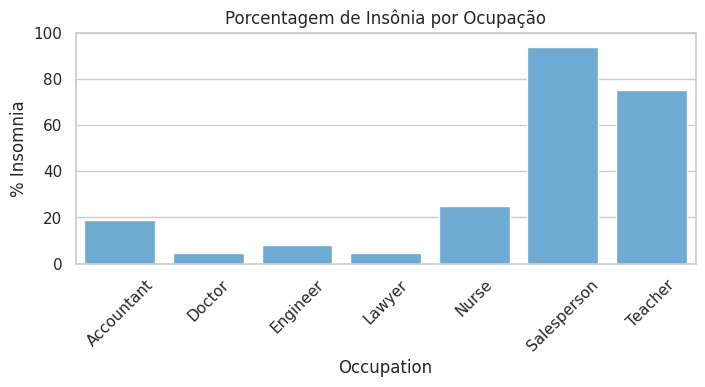

In [ ]:
# Calcular porcentagem de insônia por ocupação
observed_table['% Insomnia'] = observed_table['Insomnia'] / (observed_table['No_Insomnia'] + observed_table['Insomnia']) * 100

# Gráfico de barras

cores = ["#5DADE2", "#F5B041", "#58D68D", "#AF7AC5", "#F1948A", "#F8C471", "#85C1E9"]

plt.figure(figsize=(8, 3))
sns.barplot(data=observed_table.reset_index(), x='Occupation', y='% Insomnia', color = "#5DADE2")
plt.title("Porcentagem de Insônia por Ocupação")
plt.xticks(rotation=45)
plt.ylim(0, 100)
plt.show()

### **Conclusões Finais:**

Ocupações de Alto Risco de Insônia:
Salesperson (29/31 = 93.5% com insônia)
Teacher (27/36 = 75% com insônia)

Ocupações de Baixo Risco:
Doctor, Engineer, Lawyer, Accountant (proporções de insônia < 10%, exceto Nurse).

Nurse tem uma proporção intermediária (3/12 = 25%), mas não difere significativamente das demais após correção rigorosa.

---------------------------------------------------------------------------

## **Teste 3**

Vamos comparar o desempenho de 35 vendedores ao utilizar o método
convencional de vendas e o método obtido pelo treinamento com a empresa
VendaPro Academy, medindo o tempo de trabalho em horas necessário
para alcançar uma meta de 10 contratos vendidos. O interesse é verificar se o método da empresa VendaPro Academy é realmente superior ao método convencional da empresa.

### **Hipóteses**

**Hipótese nula (H₀): μ
d
​
 ≤0**

*O método da VendaPro Academy não é superior ao método convencional. Ou seja, o tempo médio do VendaPro é igual ou maior que o do Convencional.*

**Hipótese alternativa (H₁): μ
d
​>0**

*O método da VendaPro Academy é superior ao método convencional. Ou seja, o tempo médio do VendaPro é menor que o do Convencional*




**Nível de significância: α = 0.02**

### **Análise dos Dados**

In [ ]:
# Carregar o dataset
df = pd.read_csv('TreinamentoVendedores.csv')
df.head()

,Funcionário,Convencional,VendaPro
0,1,52.483571,38.895782
1,2,49.308678,46.044318
2,3,53.238443,35.201649
3,4,57.615149,38.359070
4,5,48.829233,45.984306


In [ ]:
# Diferença entre o tempo do método Convencional e VendaPro para cada vendedor
df['Diferença'] = df['Convencional'] - df['VendaPro']

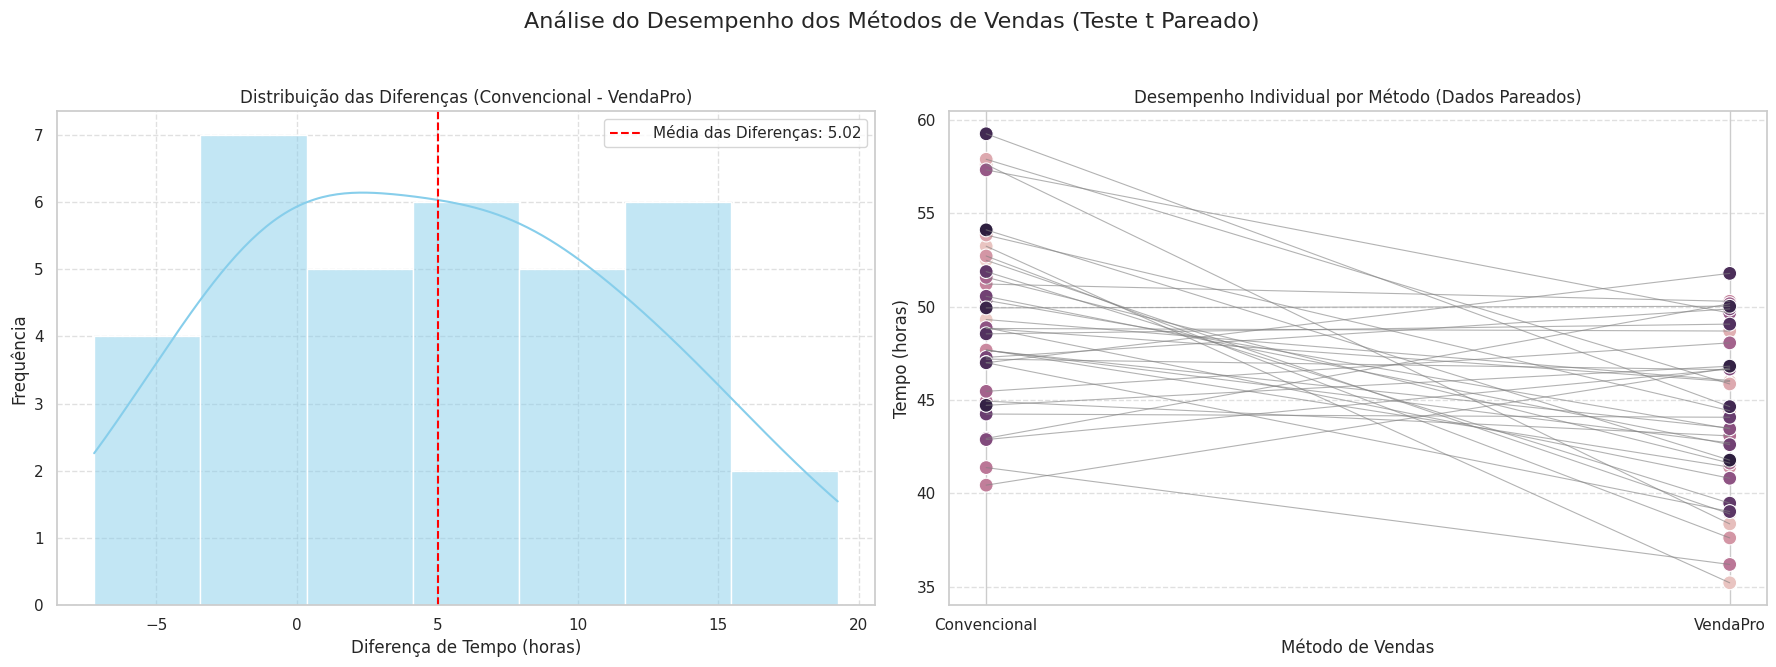

In [ ]:
# Gráficos

# Cria uma figura com 1 linha e 2 colunas de subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Gráfico 1: Histograma das Diferenças ---
sns.histplot(df['Diferença'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribuição das Diferenças (Convencional - VendaPro)')
axes[0].set_xlabel('Diferença de Tempo (horas)')
axes[0].set_ylabel('Frequência')
axes[0].axvline(df['Diferença'].mean(), color='red', linestyle='--', label=f'Média das Diferenças: {df["Diferença"].mean():.2f}')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# --- Gráfico 2: Gráfico de Dispersão com Linhas Conectando Pares ---
# Para visualizar a natureza pareada dos dados
# Reorganiza os dados para o plot
plot_df = pd.DataFrame({
    'Método': ['Convencional'] * len(df) + ['VendaPro'] * len(df),
    'Tempo': df['Convencional'].tolist() + df['VendaPro'].tolist(),
    'Vendedor': list(range(len(df))) * 2 # Cria um ID para cada vendedor
})

# Plota os pontos
sns.scatterplot(x='Método', y='Tempo', data=plot_df, hue='Vendedor', s=100, ax=axes[1], legend=False)

# Adiciona linhas conectando os pontos para cada vendedor
for i in range(len(df)):
    axes[1].plot(['Convencional', 'VendaPro'], [df['Convencional'][i], df['VendaPro'][i]], color='gray', linestyle='-', linewidth=0.8, alpha=0.6)

axes[1].set_title('Desempenho Individual por Método (Dados Pareados)')
axes[1].set_xlabel('Método de Vendas')
axes[1].set_ylabel('Tempo (horas)')
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

plt.suptitle('Análise do Desempenho dos Métodos de Vendas (Teste t Pareado)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show() # Exibe a figura com ambos os gráficos

### **Teste do Pressuposto de Normalidade**

Sobre o desempenho dos 35 vendedores e os métodos Convencional e VendaPro Academy, foi comparado o desempenho dos mesmos 35 vendedores em duas condições diferentes (método convencional e método VendaPro), o que significa que os dados são dependentes ou "pareados". Dessa forma, o teste mais adequado é o Teste t Pareado.

**Para tanto, precisamos testar a normalidade dos dados para a diferença das duas amostras**

In [ ]:
#Teste de Normalidade
## Hipótese Nula (H 0​): As diferenças entre os tempos seguem uma distribuição normal.
## Hipótese Alternativa (H 1​): As diferenças entre os tempos não seguem uma distribuição normal.

alpha = 0.02

shapiro_test = stats.shapiro(df['Diferença'])
print(f"Estatística do Teste de Shapiro-Wilk: {shapiro_test.statistic:.3f}")
print(f"Valor-p do Teste de Shapiro-Wilk: {shapiro_test.pvalue:.3f}")

Estatística do Teste de Shapiro-Wilk: 0.977
Valor-p do Teste de Shapiro-Wilk: 0.671


**Conclusão:** O p-valor do teste de Shapiro-Wilk para as diferenças foi alto (0.671), indicando que não há evidências para rejeitar H
0
​
 . Portanto, a suposição de normalidade das diferenças foi atendida, permitindo o uso do Teste t Pareado.

### **Teste t pareado**

In [ ]:
# Realiza o Teste t Pareado
# Nossa hipótese alternativa é que VendaPro é superior (tempo menor), então Convencional - VendaPro deve ser > 0.

t_statistic, p_value = stats.ttest_rel(df['Convencional'], df['VendaPro'],
                                       alternative = 'greater')

# Exibir os resultados de forma mais legível
print(f"Teste t de Student - Estatística de Teste: {round(t_statistic, 3)}, P-valor: {round(p_value, 4)}")
print(f"Região-crítica: {stats.t.ppf(1 - alpha, 6).round(3)}")

if p_value < alpha:
    print("Conclusão: Rejeitamos a hipótese nula.\n"
          "Há evidências estatísticas de que o método da VendaPro Academy é superior ao método convencional.\n"
          "Ou seja, o tempo para atingir a meta é menor.")
else:
    print("Conclusão: Não rejeitamos a hipótese nula.\n"
          "Não há evidências estatísticas de que o método da VendaPro Academy seja superior ao método convencional.")

Teste t de Student - Estatística de Teste: 4.255, P-valor: 0.0001
Região-crítica: 2.612
Conclusão: Rejeitamos a hipótese nula.
Há evidências estatísticas de que o método da VendaPro Academy é superior ao método convencional.
Ou seja, o tempo para atingir a meta é menor.


### **Conclusão Final:**

A Estatística t foi 4.255 e o valor-p foi 0.0001.

Considerando um nível de significância de 2% (α=0.02), como o valor-p (0.0001) é menor que α, rejeitamos a hipótese nula (H
0
​
 ).

Dessa forma, há evidências estatísticas significativas de que o método da VendaPro Academy é realmente superior ao método convencional, pois o tempo médio necessário para atingir a meta de 10 contratos vendidos é significativamente menor com o VendaPro Academy.

---------------------------------------------------------------------------

## **Teste 4**

O objetivo central deste estudo é testar a hipótese de que existe uma diferença significativa no tempo, em horas, que as pessoas dedicam
diariamente à audição de música, com base em seus gêneros musicais
favoritos.

### **Hipóteses**

**Hipótese Nula (H₀):** As distribuições do tempo diário dedicado à audição de música são iguais entre os diferentes gêneros musicais favoritos. Isto é, não há diferença significativa no tempo diário entre os grupos.

**Hipótese Alternativa (H₁):** Pelo menos um dos gêneros musicais favoritos apresenta uma distribuição diferente no tempo diário dedicado à audição de música.Isto é, há diferença significativa entre pelo menos dois grupos.



**Nível de significância: α = 0.05**

### **Análise dos Dados**

In [ ]:
# Carregar o conjunto de dados
df = pd.read_csv('Musicas.csv')
df.head()

,Timestamp,Age,Primary streaming service,Hours per day,While working,Instrumentalist,Composer,Fav genre,Exploratory,Foreign languages,...,Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music],Anxiety,Depression,Insomnia,OCD,Music effects,Permissions
0,8/27/2022 19:57:31,63.0,Pandora,1.5,Yes,No,No,Rock,Yes,No,...,Sometimes,Rarely,Very frequently,Rarely,7.0,2.0,2.0,1.0,NaN,I understand.
1,8/27/2022 21:28:18,18.0,Spotify,4.0,No,No,No,Video game music,No,Yes,...,Never,Rarely,Rarely,Very frequently,7.0,7.0,10.0,2.0,No effect,I understand.
2,8/27/2022 21:54:47,18.0,Spotify,4.0,Yes,No,No,R&B,Yes,No,...,Very frequently,Very frequently,Never,Rarely,7.0,2.0,5.0,9.0,Improve,I understand.
3,8/27/2022 22:00:29,18.0,YouTube Music,3.0,Yes,Yes,No,Video game music,Yes,Yes,...,Rarely,Never,Never,Sometimes,4.0,8.0,6.0,0.0,Improve,I understand.
4,8/27/2022 22:18:59,21.0,Spotify,1.0,Yes,No,No,K pop,Yes,Yes,...,Sometimes,Rarely,Never,Rarely,5.0,3.0,5.0,3.0,Improve,I understand.


In [ ]:
#  Exibir a dimensão da tabela
print(f"Dimensão da tabela: {df.shape[0]} linhas e {df.shape[1]} colunas.\n")

Dimensão da tabela: 697 linhas e 33 colunas.



In [ ]:
#  Tratar valores ausentes na coluna 'Hours per day' com a mediana
# CORREÇÃO: Atribuindo o resultado de volta à coluna para evitar o FutureWarning
df['Hours per day'] = df['Hours per day'].fillna(df['Hours per day'].median())

#  Obter os gêneros musicais únicos
genres = df['Fav genre'].unique()

# Remover 'NaN' da lista de gêneros, se houver
genres = [g for g in genres if pd.notna(g)]

### **Teste dos Pressupostos**

#### **Teste de Normalidade dos Dados**

In [ ]:
# Realizar o Teste de Normalidade (Shapiro-Wilk) para cada gênero
normality_results = {}
for genre in genres:
    # Filtrar os dados de 'Hours per day' para o gênero atual e remover NaNs
    genre_data = df[df['Fav genre'] == genre]['Hours per day'].dropna()

    # O teste de Shapiro-Wilk requer no mínimo 4 pontos de dados
    if len(genre_data) >= 4:
        shapiro_test = stats.shapiro(genre_data)
        normality_results[genre] = {'Statistic': shapiro_test.statistic, 'P-value': shapiro_test.pvalue}
    else:
        normality_results[genre] = {'Statistic': 'N/A', 'P-value': 'Not enough data'}

# Exibir os resultados do Teste de Normalidade em formato de tabela
print("\nResultados do Teste de Normalidade (Shapiro-Wilk):\n")
normality_df = pd.DataFrame.from_dict(normality_results, orient='index')
print(normality_df.to_markdown(numalign="left", stralign="left"))


Resultados do Teste de Normalidade (Shapiro-Wilk):

|                  | Statistic   | P-value     |
|:-----------------|:------------|:------------|
| Rock             | 0.754737    | 2.09046e-16 |
| Video game music | 0.829865    | 1.39597e-05 |
| R&B              | 0.845734    | 0.0001848   |
| K pop            | 0.796729    | 0.000154999 |
| Country          | 0.893334    | 0.0131725   |
| EDM              | 0.81258     | 2.3577e-05  |
| Hip hop          | 0.818544    | 4.81469e-05 |
| Pop              | 0.815819    | 1.25428e-10 |
| Rap              | 0.611988    | 1.79217e-06 |
| Classical        | 0.931932    | 0.00482189  |
| Metal            | 0.843142    | 3.19075e-08 |
| Folk             | 0.918505    | 0.0245332   |


 **Gráficos QQ-plot Combinados para "Horas por Dia" por Gênero Musical**

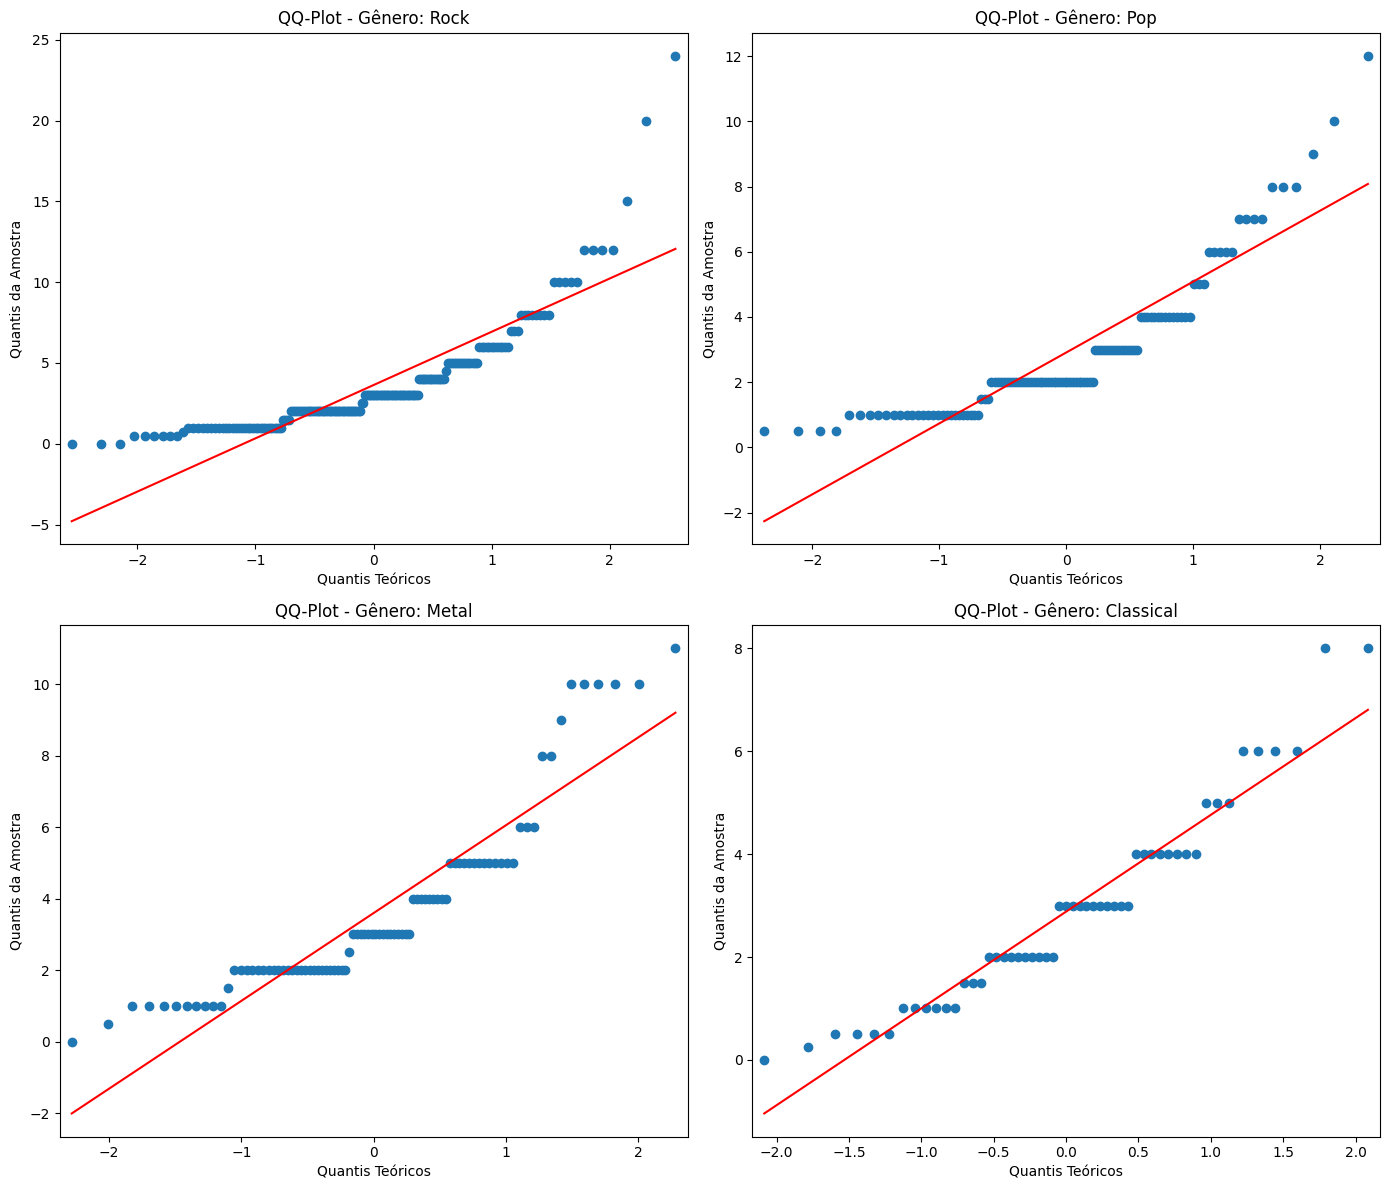

In [ ]:
# Obter os 4 gêneros musicais mais frequentes para visualização
top_genres = df['Fav genre'].value_counts().nlargest(4).index.tolist()

#  Criar subplots para os gráficos QQ-plot
fig, axes = plt.subplots(2, 2, figsize=(14, 12)) # 2 linhas, 2 colunas
axes = axes.flatten() # Achatar o array de eixos para fácil iteração

for i, genre in enumerate(top_genres):
    genre_data = df[df['Fav genre'] == genre]['Hours per day'].dropna()

    if len(genre_data) >= 4: # QQ-plot é significativo com dados suficientes
        sm.qqplot(genre_data, line='s', ax=axes[i]) # 's' para linha padronizada
        axes[i].set_title(f"QQ-Plot - Gênero: {genre}")
        axes[i].set_xlabel("Quantis Teóricos")
        axes[i].set_ylabel("Quantis da Amostra")
    else:
        axes[i].set_title(f"Dados insuficientes para {genre}")
        axes[i].axis('off') # Ocultar o subplot se não houver dados suficientes

#  Ajustar o layout e exibir o gráfico
plt.tight_layout()
plt.show()

**Conclusão de Normalidade:**
Os gráficos acima mostram a distribuição das "Horas por Dia" para os gêneros Rock, Pop, Metal e Classical. É possível observar nesses gráficos que os pontos se desviam significativamente da linha, especialmente nas extremidades. Isso sugere visualmente que a distribuição das "Horas por Dia" não é normal para esses gêneros, oque complementa **os resultados do teste de Shapiro-Wilk, que já havia indicado a não-normalidade dos dados numericamente.**

#### **Teste de Homogeneidade das Variâncias**

textH_0: As variâncias dos grupos são iguais.

textH_1: As variâncias de pelo menos um grupo são diferentes.

In [ ]:
# Preparar os dados para o Teste de Levene
genre_groups_levene = [df[df['Fav genre'] == genre]['Hours per day'].dropna()
for genre in genres if len(df[df['Fav genre'] == genre]
 ['Hours per day'].dropna()) > 1]

if len(genre_groups_levene) > 1:
    levene_test = stats.levene(*genre_groups_levene)
    print(f"Teste de Levene para Homogeneidade de Variâncias: Estatística={levene_test.statistic:.3f}, Valor-p={levene_test.pvalue:.3f}\n")
else:
    print("Não há grupos suficientes para realizar o Teste de Levene.\n")

Teste de Levene para Homogeneidade de Variâncias: Estatística=2.145, Valor-p=0.016



**Conclusão de Homogeneidade:**
Com um valor-p de 0.016 (menor que o nível de significância de 0.05), rejeitamos a hipótese nula de que as variâncias são iguais. Isso indica que as variâncias de "Horas por dia" são significativamente diferentes entre os gêneros musicais.

#### **Gráficos**

um gráfico de box plot agrupado para todos os gêneros musicais ajuda a visualizar a distribuição das "Horas por dia" em cada grupo, mostrando as diferenças gerais detectadas e as variâncias entre os grupos.

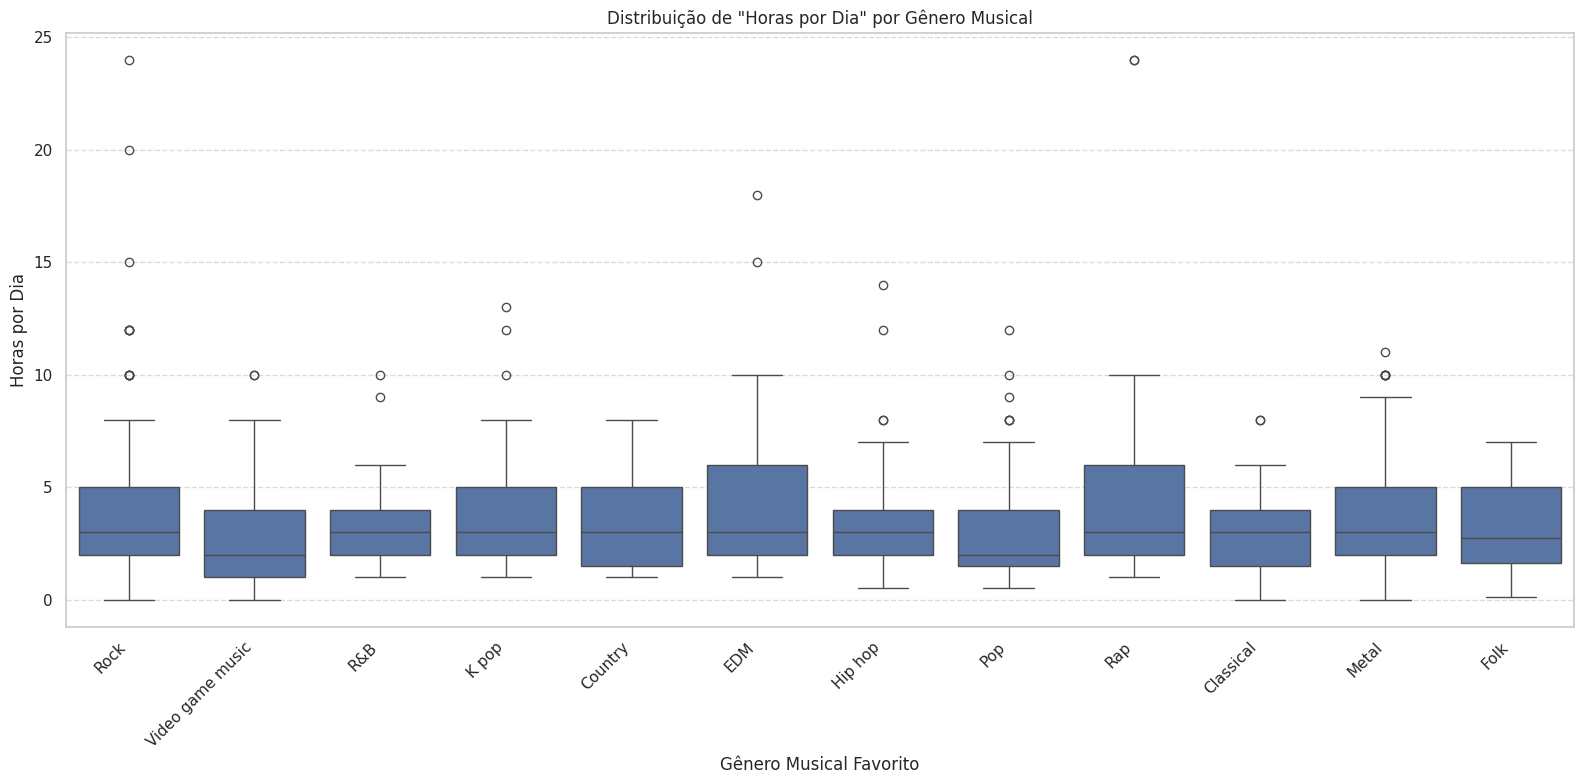


Gráfico 'boxplot_all_genres_hours_per_day.png' gerado para visualização das distribuições por gênero.


In [ ]:
# Gráfico: Box Plot Agrupado para "Horas por Dia" por Gênero
plt.figure(figsize=(16, 8))
sns.boxplot(x='Fav genre', y='Hours per day', data=df)
plt.title('Distribuição de "Horas por Dia" por Gênero Musical')
plt.xlabel('Gênero Musical Favorito')
plt.ylabel('Horas por Dia')
plt.xticks(rotation=45, ha='right') # Rotaciona os rótulos do eixo X para melhor visualização
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\nGráfico 'boxplot_all_genres_hours_per_day.png' gerado para visualização das distribuições por gênero.")

#### Pelo teste de Normalidade e pelo teste de Homogeneidade, temos que os pressupostos para usar o teste Anova não foram atendidos. Dessa forma, é necessário fazer um teste não paramétrico.

### **Teste estatístico de Kruskall Wallis**

In [ ]:
#Como indicado na questão, usando o pacote pingouin para facilitar

resultado = pg.kruskal(data=df, dv='Hours per day', between='Fav genre')
print(resultado)

            Source  ddof1          H     p-unc
Kruskal  Fav genre     11  17.024857  0.107142


### **Conclusão Final**

Com base no teste de Kruskal-Wallis, não foi encontrada evidência estatisticamente significativa de diferença no tempo diário dedicado à audição de música entre os diferentes gêneros musicais favoritos. (p-unc = 0,107142 > 0,05).

Portanto, não rejeitamos a hipótese nula, concluindo que as distribuições de tempo de escuta são estatisticamente semelhantes entre os grupos analisados.

---------------------------------------------------------------------------

# **Teste 5**

Nessa questão, o objetivo é verificar se o comportamento do treinador durante o treinamento pode ter efeito significativo no desempenho das equipes na corrida. Caso seja verificada a diferença, o interesse é saber quais comportamentos têm tempo menor (impacto positivo).

### **Hipóteses:**

**Hipótese Nula (H₀):** As médias dos tempos de corrida são iguais entre os diferentes tipos de treinador (Não há diferença entre os desempenhos das equipes na corrida, comportamento do treinador impacta)

**Hipótese Alternativa (H₁):** Pelo menos um dos tipos de treinador gera média de tempo significativamente diferente. (Há diferença entre os desempenhos das equipes na corrida, comportamento do treinador não impacta)


**Nível de significância: α = 0.05**

### **Análise dos dados**

In [ ]:
# Importando os dados
df_impacto = pd.read_csv('ImpactoTreinador.csv')
df_impacto.head()

,Equipe,Semana,Tipo de Treinador,Tempo de Corrida
0,1,1,Motivador,42.483571
1,1,1,Rigoroso,46.308678
2,1,1,Colaborador,53.238443
3,1,1,Analítico,47.615149
4,2,1,Motivador,38.829233


In [ ]:
# Pra visualizar quais tipos de treinador consta na base
equipe = df_impacto['Equipe'].unique()
semana = df_impacto['Semana'].unique()
treinador = df_impacto['Tipo de Treinador'].unique()

print(f"Equipes: {equipe}\n"
      f"Semanas: {semana}\n"
      f"Tipos de Treinador: {treinador}")

Equipes: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
Semanas: [1]
Tipos de Treinador: ['Motivador' 'Rigoroso' 'Colaborador' 'Analítico']


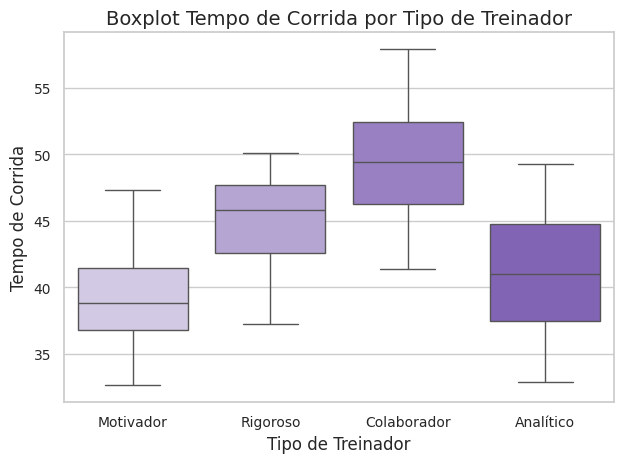

In [ ]:
# Boxplot para analisar o comportamento do tempo de corrida por treinador

cores = ["#D1C4E9", "#B39DDB", "#9575CD", "#7E57C2"]

sns.set(style="whitegrid")
sns.boxplot(data=df_impacto, x='Tipo de Treinador', y='Tempo de Corrida',
            hue='Tipo de Treinador', palette=cores)

plt.title('Boxplot Tempo de Corrida por Tipo de Treinador', fontsize = 14)
plt.ylabel('Tempo de Corrida', fontsize = 12)
plt.xlabel('Tipo de Treinador', fontsize = 12)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

Pela análise do gráfico acima, parece existir uma diferença entre as médias de tempos de cada treinador, principalmente entre os motivadores e os colaboradores. Apesar de pelas estatísticas básicas de média, mediana e dispersões, aparentar existir diferença, é necessário fazer um teste estatístico que comprove.

### **Teste de Hipótese**

Considerando os dados apresentados, será aplicado um teste ANOVA para medidas repetidas, com dados longitudinais, uma vez que as mesmas equipes foram analisadas por 15 semanas, mudando o tipo de trinador. Para tanto, é necessário ver se as condições para o teste são atendidas:

* As populações têm distribuição que são aproximadamente normais;
* As amostras são aleatórias simples;
* Há esfericidade dos grupos. (Essa suposição também é conhecida como suposição de homogeneidade da variância das diferenças.);
* As respostas dos sujeitos (variável dependente) devem ser contínuas;
* Independência das Respostas (dentro do mesmo grupo);
* Não deve haver valores discrepantes

Pela análise dos dados, já sabemos que as amostras são aleatórias simples, as respostas são contínuas; as respostas são independentes e não há valores discrepantes. Assim é necessário testar a normalidade dos dados e a homogeniedade da variância das diferenças.

#### **Testes dos Pressupostos de Normalidade e Esfericidade (homogeniedade da variância das diferenças)**

In [ ]:
alfa = 0.05

In [ ]:
# Teste de Normalidade
pg.normality(df_impacto, dv='Tempo de Corrida', group='Tipo de Treinador', alpha = alfa)

,W,pval,normal
Tipo de Treinador,,,
Motivador,0.983104,0.986346,True
Rigoroso,0.889554,0.066026,True
Colaborador,0.986417,0.995840,True
Analítico,0.948974,0.508432,True


In [ ]:
# Teste de Esfericidade (homogeniedade da variância das diferenças)
spher, _, chisq, dof, pval =  pg.sphericity(data=df_impacto,
                                            dv='Tempo de Corrida',
                                            subject='Equipe',
                                            within=['Tipo de Treinador'],
                                            alpha = alfa)

# Exibir os resultados de forma mais informativa
print(f"Teste de Mauchly para Esfericidade:")
print(f"Esfericidade Atingida: {spher}")
print(f"Estatística Qui-Quadrado: {round(chisq, 3)}")
print(f"Graus de Liberdade: {dof}")
print(f"Valor-p: {round(pval, 3)}")

# Decidir sobre a esfericidade com base no valor-p
if pval < 0.05:
    print("Rejeitar H0: Esfericidade Não Atingida")
else:
    print("Não rejeitar H0: Esfericidade Atingida")

Teste de Mauchly para Esfericidade:
Esfericidade Atingida: True
Estatística Qui-Quadrado: 2.088
Graus de Liberdade: 5
Valor-p: 0.837
Não rejeitar H0: Esfericidade Atingida


**Conclusão Testes dos Pressupostos**:

Os testes acimam mostram que os pressupostos de normalidade e de esfericidade foram atingidos, isto é, as hipóteses nulas não foram rejeitadas ao nível de significância de 5%.

*Ressalta-se a importância da não rejeição do teste de esferecidade, uma vez que, se as variâncias são iguais, a diferença está penas na média (o que é o interesse do teste).*

#### **Teste de hipótese - Anova para medidas repetidas**

In [ ]:
aov = pg.rm_anova(dv = 'Tempo de Corrida', within = 'Tipo de Treinador',
                  subject = 'Equipe', data = df_impacto, detailed = False)
pg.print_table(aov)


ANOVA SUMMARY

Source               ddof1    ddof2       F    p-unc    ng2    eps
-----------------  -------  -------  ------  -------  -----  -----
Tipo de Treinador        3       42  15.613    0.000  0.448  0.898



#### **Post Hocs**

In [ ]:
posthocs = pg.pairwise_tests(dv='Tempo de Corrida', within='Tipo de Treinador',
                             subject='Equipe', data=df_impacto ,
                             padjust = 'bonf', alpha = alfa)

pg.print_table(posthocs, floatfmt='.2f', tablefmt= 'simple')
# print(posthocs)


POST HOC TESTS

Contrast           A            B            Paired    Parametric        T    dof  alternative      p-unc    p-corr  p-adjust       BF10    hedges
-----------------  -----------  -----------  --------  ------------  -----  -----  -------------  -------  --------  ----------  -------  --------
Tipo de Treinador  Analítico    Colaborador  True      True          -5.34  14.00  two-sided         0.00      0.00  bonf         275.21     -1.70
Tipo de Treinador  Analítico    Motivador    True      True           0.73  14.00  two-sided         0.48      1.00  bonf           0.33      0.30
Tipo de Treinador  Analítico    Rigoroso     True      True          -2.50  14.00  two-sided         0.03      0.15  bonf           2.63     -0.83
Tipo de Treinador  Colaborador  Motivador    True      True           6.81  14.00  two-sided         0.00      0.00  bonf        2572.10      2.31
Tipo de Treinador  Colaborador  Rigoroso     True      True           3.40  14.00  two-sided         

<Axes: xlabel='Tipo de Treinador', ylabel='Tempo de Corrida'>

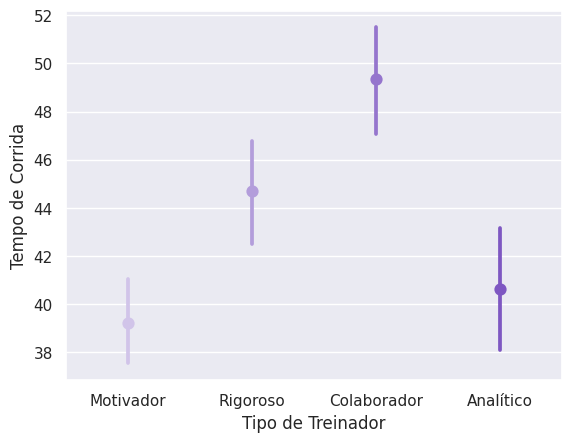

In [ ]:
sns.set()
sns.pointplot(data=df_impacto, x='Tipo de Treinador',
              y='Tempo de Corrida', hue='Tipo de Treinador', palette=cores)

### **Conclusão Final do Teste:**

Considerando que os pressupostos de normalidade e esfericidade foram atendidos, foi realizado o teste de ANOVA para medidas repetidas com o objetivo de verificar se há diferença significativa no tempo de corrida em função do tipo de treinador.

A análise do resultado revelou um valor de p não corrigido (p-unc) igual a 0.000, ou seja, um valor de significância associado à estatística F inferior a 0,05. **Isso indica que há diferença estatisticamente significativa no tempo de corrida entre os diferentes tipos de treinador. Além disso, o valor do tamanho de efeito (η²g = 0,448) aponta que o tipo de treinador tem um impacto expressivo sobre o desempenho das equipes, sendo considerado um efeito de grande magnitude.**

Sabendo que existe diferença global, é relevante identificar entre quais grupos essas diferenças ocorrem. A análise Post Hoc, com valores de p corrigidos, indica que há diferenças estatisticamente significativas entre todas as categorias de treinadores, com exceção dos pares: Motivador vs. Analítico e Analítico vs. Rigoroso.

Por fim, ao analisar os valores de T, observa-se que **a categoria Motivador foi aquela que apresentou, de forma mais consistente, menor tempo de corrida nas comparações em que foi incluída**, destacando-se especialmente nas comparações com Colaborador e Rigoroso.